In [1]:
import json
import os

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaConfig, RobertaForMaskedLM, PreTrainedTokenizerFast
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import pandas as pd
import utils.data as data

device = torch.device("mps")
dataset = data.OpcodeDataset()

BATCH_SIZE = 128
LR = 5e-5
EPOCHS = 1
MAX_LEN = 64

# Create Tokenizer 

In [3]:
if not os.path.exists("./opcode_tokenizer.json"):
    from tokenizers import Tokenizer, models, pre_tokenizers, trainers

    vocab = json.load(open("vocab.json", "r"))
    tokenizer = Tokenizer(models.WordLevel(unk_token="[UNK]"))
    tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

    trainer = trainers.WordLevelTrainer(
        min_frequency=1, special_tokens=["[PAD]", "[MASK]"]
    )
    tokenizer.train_from_iterator(vocab, trainer)

    tokenizer.save("opcode_tokenizer.json")

## Load tokenizer

In [2]:
tokenizer = PreTrainedTokenizerFast(tokenizer_file="./opcode_tokenizer.json")

# Tokenize Data

In [5]:
if not os.path.exists(
    "/Volumes/New Volume/malware-detection-dataset/opcodes/tokenized_sequences.json"
):
    tokenized_sequences = [
        tokenizer.encode(instructions).ids
        for instructions, _ in tqdm(dataset, desc="Tokenizing...")
    ]
    json.dump(
        tokenized_sequences,
        open(
            "/Volumes/New Volume/malware-detection-dataset/opcodes/tokenized_sequences.json",
            "w",
        ),
    )

In [3]:
tokenized_sequences = json.load(
    open(
        "/Volumes/New Volume/malware-detection-dataset/opcodes/tokenized_sequences.json",
        "r",
    )
)

# Create Dataset

In [4]:
class OpcodeDataset(Dataset):
    def __init__(self, tokenized_sequences, vocab_size: int, mask_prob: float = 0.15):
        self.sequences = tokenized_sequences
        self.mask_prob = mask_prob
        self.vocab_size = vocab_size

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        tokens = self.sequences[idx].copy()

        processed = np.zeros(MAX_LEN, dtype=np.int64)
        attention_mask = np.ones(MAX_LEN, dtype=np.int64)
        labels = np.full(MAX_LEN, -100)

        start = np.random.randint(0, len(tokens))

        selected = tokens[start : start + MAX_LEN]
        processed[: len(selected)] = selected
        attention_mask[processed == 0] = 0

        for i, token in enumerate(processed):
            if token == 0:
                continue
            if np.random.random() < self.mask_prob:
                # Token selected for masking
                labels[i] = token
                q = np.random.random()

                if q < 0.8:
                    # Replace token with mask (80%)
                    processed[i] = tokenizer.encode("[MASK]")[0]
                elif q < 0.9:
                    # Replace token with random token (10%)
                    processed[i] = np.random.randint(2, self.vocab_size)
                else:
                    # Leave as is
                    pass
        return {
            "input_ids": torch.tensor(processed),
            "attention_mask": torch.tensor(attention_mask),
        }, torch.tensor(labels)


train_sequences, test_sequences = train_test_split(tokenized_sequences)

train = OpcodeDataset(train_sequences, tokenizer.vocab_size)
train_loader = DataLoader(train, batch_size=BATCH_SIZE, shuffle=True)
test = OpcodeDataset(test_sequences, tokenizer.vocab_size)
test_loader = DataLoader(test, batch_size=BATCH_SIZE, shuffle=True)

In [8]:
input, labels = train[np.random.randint(len(train))]
print(f"Masked tokens at {np.argwhere(labels != -100)}")

pd.DataFrame(
    {
        "Tokens": input["input_ids"],
        "Opcode": tokenizer.decode(
            list(input["input_ids"]), skip_special_tokens=False
        ).split(" "),
        "Mask": input["attention_mask"],
        "Labels": labels,
    }
).transpose()

Masked tokens at tensor([[ 8, 21, 35, 36, 52, 53, 58, 60, 62]])

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
Tokens,8,243,518,22,569,376,680,22,1,8,...,680,22,350,8,1,376,1,376,1,298
Opcode,add,fstp,pop,and,push,mov,test,and,[MASK],add,...,test,and,lodsb,add,[MASK],mov,[MASK],mov,[MASK],jmp
Mask,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
Labels,-100,-100,-100,-100,-100,-100,-100,-100,8,-100,...,-100,-100,-100,-100,376,-100,22,-100,8,-100


# Create Model

In [5]:
config = RobertaConfig(
    vocab_size=tokenizer.vocab_size,
    max_position_embeddings=MAX_LEN,
    num_attention_heads=6,
    num_hidden_layers=3,
    type_vocab_size=1,
    hidden_size=252,
    intermediate_size=512,
)

model = RobertaForMaskedLM(config)
model = model.to(device)

# Train Model

In [6]:
def test(model, test_loader):
    model.eval()
    test_loss = 0.0

    test_loop = tqdm(
        test_loader, desc=f"Test Epoch {epoch + 1}/{EPOCHS}", leave=False, unit="batch"
    )

    for tokens, labels in test_loop:
        input_ids, attention_mask = tokens.values()
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            output = model(input_ids, attention_mask, labels=labels)

        test_loss += output.loss.item()
    model.train()
    return test_loss / len(test_loader)


optimizer = AdamW(model.parameters(), lr=LR)
losses = []
test_losses = []

for epoch in range(EPOCHS):
    test_losses.append(test(model, test_loader))
    train_loop = tqdm(
        train_loader,
        desc=f"Train Epoch {epoch + 1}/{EPOCHS}",
        unit="batch",
        leave=False,
    )
    for input, labels in train_loop:
        input_ids, attention_mask = input.values()
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        output = model(input_ids, attention_mask, labels=labels)
        loss = output.loss
        loss.backward()
        optimizer.step()
        train_loop.set_postfix_str(
            f"Loss: {loss.item():.2f}, Test Loss: {test_losses[-1]:.2f}"
        )
        losses.append(loss.item())

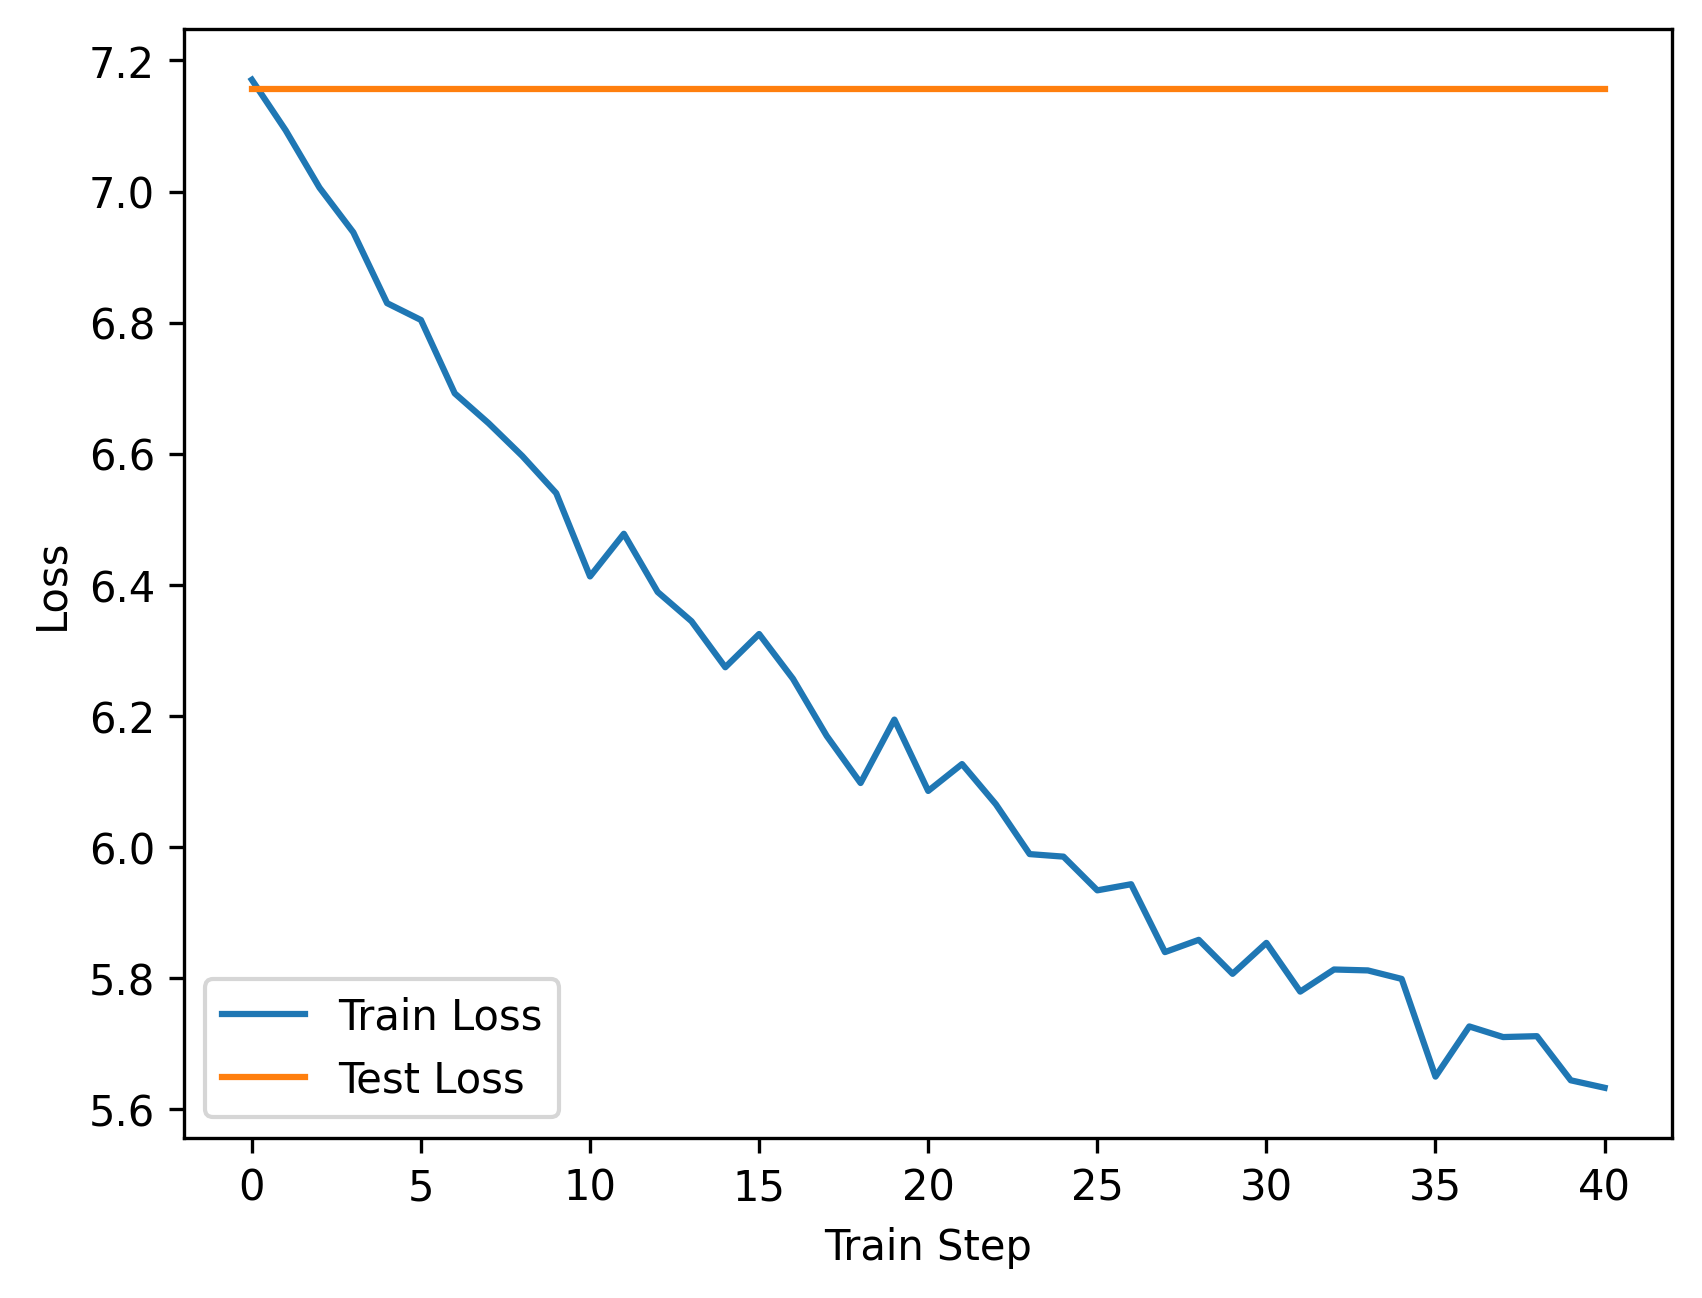

In [12]:
losses = np.array(losses)
test_losses = np.array(test_losses)

test_loss_steps = np.linspace(0, len(losses) - 1, num=len(test_losses))
test_loss_interpolated = np.interp(np.arange(len(losses)), test_loss_steps, test_losses)

plt.figure(dpi=300)
plt.plot(losses, label="Train Loss")
plt.plot(test_loss_interpolated, label="Test Loss")
plt.legend()
plt.xlabel("Train Step")
plt.ylabel("Loss")
plt.show()

In [7]:
test_loop = tqdm(test_loader, desc="Evaluation", leave=False, unit="batch")

actual = []
predicted = []
was_masked = []
for input, labels in test_loop:
    input_ids, attention_mask = input.values()
    input_ids = input_ids.to(device)
    attention_mask = attention_mask.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        output = model(input_ids, attention_mask, labels=labels)

    input_ids = input_ids.cpu()
    labels = labels.cpu()
    output = output.logits.cpu()

    gt = np.zeros_like(labels)
    gt[labels == -100] = input_ids[labels == -100]
    gt[labels != -100] = labels[labels != -100]
    mask = labels != -100

    actual.append(gt)
    predicted.append(output.argmax(dim=-1))
    was_masked.append(mask)

In [8]:
actual = np.array([gt for batch in actual for gt in batch])
predicted = np.array([pred for batch in predicted for pred in batch])
was_masked = np.array([mask for batch in was_masked for mask in batch])

actual.shape == predicted.shape

True

In [17]:
idxs = np.random.randint(0, len(actual), 5)

df = pd.DataFrame(
    {
        "ID": idxs,
        "Actual": [tokenizer.decode(gt) for gt in actual[idxs]],
        "Predicted": [tokenizer.decode(y_hat) for y_hat in predicted[idxs]],
        "Correct %": [
            np.count_nonzero((y == y_hat) & mask) / np.count_nonzero(mask)
            for y, y_hat, mask in zip(actual[idxs], predicted[idxs], was_masked[idxs])
        ],
    }
)

df

,ID,Actual,Predicted,Correct %
0,1005,or add add cmp cmp jae adc xchg add add cmp cm...,add add add add add add mov add add add add ad...,0.250000
1,1502,add call mov add add test ror je test add add ...,add add add add add add add add add add add ad...,0.500000
2,1104,or sub or jb cmp add jo or fisub pushal add pu...,add add add add add add add add add add add ad...,0.307692
3,544,add push lea inc fsubr push add push call sub ...,add add add add add mov add add add add add ad...,0.071429
4,846,sub mov mov push and and mov mov and and sub m...,add add add add add add mov mov add add add ad...,0.142857


In [ ]:
correct = np.array(
    [
        [np.count_nonzero((y == y_hat) & mask), np.count_nonzero(mask)]
        for y, y_hat, mask in zip(actual, predicted, was_masked)
        if np.count_nonzero(mask) > 0
    ]
)

np.mean(correct[:, 0] / correct[:, 1])

np.float64(0.15755875194910773)